In [7]:
import numpy as np
import math

In [8]:
class Node:
    def __init__(self,data,_child=(),_op='',label=''):
        self.data = float(data)
        self._prev = set(_child)
        self._op = _op
        self.label = label
        self.grad = 0.0
        self._backward = lambda : None

    def __repr__(self):
        return f"Node(data={self.data})"   
        
    #-------------------------------------------------------------------------------------
    
    def __add__(self,other):
        other=other if isinstance(other,Node) else Node(other)
        out=Node(self.data + other.data, (self,other), '+')

        def _backward():
            self.grad += out.grad
            other.grad += out.grad

        out._backward=_backward
        return out
        
    def __mul__(self,other):
        other=other if isinstance(other,Node) else Node(other)
        out=Node(self.data * other.data, (self,other), '*')

        def _backward():
            self.grad += out.grad * other.data
            other.grad += out.grad * self.data

        out._backward=_backward    
        return out

    def __neg__(self):
        return self * (-1)
    def __sub__(self,other):
        return self + (-other)

    def __pow__(self,other):
        assert isinstance(other, (int, float)), "Only  int/float  for powers"
        out = Node(self.data ** other, (self,), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other-1)) * out.grad

        out._backward=_backward
        return out

    def __truediv__(self,other):
        return self * other ** -1
    def __rmul__(self, other): return self * other
    def __rsub__(self, other): return Node(other) + (-self)
    def __rtruediv__(self, other): return Node(other) * (self**-1)    
    def __radd__(self, other):
        return self.__add__(other)    

    def log(self):
        # Clip value slightly above 0 to avoid log(0) undefined behavior
        val = max(1e-15, self.data)
        out = Node(np.log(val), (self,), 'Log')
        
        def _backward():
            self.grad += (1.0 / val) * out.grad
        out._backward = _backward
        return out    

    #---------------------------------------------------------------------------------------------------#

    def tanh(self):
        clipped = max(-50.0, min(50.0, self.data))
        val = math.tanh(clipped)

        out = Node(val, (self,), 'Tanh')

        def _backward():
            self.grad += (1 - val**2) * out.grad

        out._backward=_backward
        return out

    def sigmoid(self):
        clipped = max(-50.0, min(50.0, self.data))
        val = 1 / (1 + np.exp(-clipped))

        out = Node(val, (self,), 'Sigmoid')

        def _backward():
            self.grad += val * (1.0 - val) * out.grad

        out._backward=_backward
        return out

    def relu(self):
        n = self.data
        val = max(0.0,n)

        out = Node(val, (self,), 'ReLU')

        def _backward():
            self.grad += (1 if val>0.0 else 0.0) * out.grad

        out._backward=_backward    
        return out

    #---------------------------------------------------------------------------------------------------#

    def backward(self):
        topo = []
        vis = set()

        def topo_sort(root):
            if root not in vis:
                vis.add(root)
                for child in root._prev:
                    topo_sort(child)
                topo.append(root)    
            
        topo_sort(self) 
        self.grad=1.0
        for i in range(len(topo)-1,-1,-1):
            topo[i]._backward()
                

In [9]:
class Neuron:
    def __init__(self,inp_size,activation='linear'):
        # He-Norm weight initialization
        lim = np.sqrt(6 / inp_size)

        self.w =[Node(np.random.uniform(-lim,lim)) for _ in range(inp_size)]
        self.b = Node(0.0)
        self.activation = activation.lower()

    def __call__(self,x):
         out = sum((wi*xi for wi,xi in zip(self.w, x)) , self.b)

         if self.activation == 'relu':
             out=out.relu()
         elif self.activation == 'sigmoid':
             out=out.sigmoid()
         elif self.activation == 'tanh':
             out=out.tanh()
            
         return out    

    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self,n_inp,n_out,activation='linear'):
        self.neurons =[Neuron(n_inp,activation) for _ in range(n_out)]

    def __call__(self,x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out)==1 else out

    def parameters(self):
        par=[]
        
        for n in self.neurons:
            pr=n.parameters()
            par.extend(pr)
            
        return par 

class ANN:
    def __init__(self,n_inp,list_layes,activations=None):
        size = [n_inp] + list_layes
        self.layers = [Layer(size[i],size[i+1],activations[i]) for i in range(len(list_layes))]

    def __call__(self,x):
        for layer in self.layers:
            x = [xi if isinstance(xi, Node) else Node(xi) for xi in (x if isinstance(x, list) else [x])]
            x = layer(x)
        return x

    def parameters(self):
        par=[]
        
        for lyr in self.layers:
            ps=lyr.parameters()
            par.extend(ps)
        return par 

In [10]:
def binary_cross_entropy_loss(y_pred, y_true):
    if not isinstance(y_pred, list): y_pred, y_true = [y_pred], [y_true]
    losses = []
    for yp, yt in zip(y_pred, y_true):
        # Formula: -[y * log(p) + (1 - y) * log(1 - p)]
        loss_val = -(yt * yp.log() + (1.0 - yt) * (1.0 - yp).log())
        losses.append(loss_val)
    return sum(losses) * (1.0 / len(losses))

In [31]:
# 1. Dataset Configuration (XOR Logic Gate)
X = [[0.0, 0.0], 
     [0.0, 1.0], 
     [1.0, 0.0], 
     [1.0, 1.0]]

Y = [0.0, 1.0, 1.0, 0.0]

# 2. Model Initialization (2 Inputs -> 4 Hidden Neurons -> 1 Output Neuron)
model = ANN(2,[4, 1],['tanh', 'sigmoid'])

# 3. Training Parameter Setup
epochs = 5000
learning_rate = 0.25

print("Beginning Training Loop...")
print("-" * 40)

for epoch in range(epochs):
    # Forward execution pass
    preds = [model(x) for x in X]
    
    # Calculate metric error cost
    loss = binary_cross_entropy_loss(preds, Y)
    
    for p in model.parameters():
        p.grad=0
    loss.backward()
        
    for p in model.parameters():
        p.data -= 0.01*p.grad
    if epoch % 100 == 0 or epoch == epochs - 1:
        print(f"Iteration : {epoch+1} --> loss : {loss.data}")     


Beginning Training Loop...
----------------------------------------
Iteration : 1 --> loss : 0.7708146822156687
Iteration : 101 --> loss : 0.687936834556881
Iteration : 201 --> loss : 0.6410266922048694
Iteration : 301 --> loss : 0.6122825995769376
Iteration : 401 --> loss : 0.59212631557975
Iteration : 501 --> loss : 0.5761897607890478
Iteration : 601 --> loss : 0.5624932068127914
Iteration : 701 --> loss : 0.5500463168453144
Iteration : 801 --> loss : 0.5383069201343638
Iteration : 901 --> loss : 0.5269496755487911
Iteration : 1001 --> loss : 0.5157565089041788
Iteration : 1101 --> loss : 0.5045634931263463
Iteration : 1201 --> loss : 0.49323796890977945
Iteration : 1301 --> loss : 0.4816743822372807
Iteration : 1401 --> loss : 0.4698018879004553
Iteration : 1501 --> loss : 0.4575955356697007
Iteration : 1601 --> loss : 0.445080250685613
Iteration : 1701 --> loss : 0.43231966197186256
Iteration : 1801 --> loss : 0.4193929163420346
Iteration : 1901 --> loss : 0.4063728952385246
Iterat

In [32]:
print("-" * 40)
print("Final Model Predictions:")
for x, y in zip(X, Y):
    prob =model(x).data
    pred_val = 1 if prob > 0.5 else 0 
    print(f"Input: {x} -> Expected: {y} | Model Probability: {prob:.4f} | Model Result: {pred_val:.1f}")

----------------------------------------
Final Model Predictions:
Input: [0.0, 0.0] -> Expected: 0.0 | Model Probability: 0.0614 | Model Result: 0.0
Input: [0.0, 1.0] -> Expected: 1.0 | Model Probability: 0.9094 | Model Result: 1.0
Input: [1.0, 0.0] -> Expected: 1.0 | Model Probability: 0.8516 | Model Result: 1.0
Input: [1.0, 1.0] -> Expected: 0.0 | Model Probability: 0.1742 | Model Result: 0.0


In [33]:
from graphviz import Digraph

def trace(root):
    nodes,edges=set(),set()

    def build(root):
        if root not in nodes:
            nodes.add(root)
            
            for child in root._prev:
                edges.add((child,root))
                build(child)

    build(root)
    return nodes,edges

def plot_grph(root):
    # Configure the global canvas for deep black mode
    dot = Digraph(format='svg', graph_attr={
        'rankdir': 'LR',
        'splines': 'spline',     
        'concentrate': 'true',  
        'bgcolor': '#000000'    
    })

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))
        
        # --- Value Nodes (Data Boxes) ---
        # Empty text space or label handling
        lbl = n.label if (hasattr(n, 'label') and n.label) else ''
        
        node_label = "{data %.4f | grad %.4f }" % (n.data, n.grad)
        
        dot.node(
            name=uid, 
            label=node_label, 
            shape='record', 
            style='solid',           # Keeps the box empty/transparent inside
            color='#FFFFFF',         # Sharp white border outlines
            fontcolor='#FFFFFF',     # Clean white text
            fontname='Helvetica',
            fontsize='10'
        )

        # --- Operation Nodes (+, *, tanh) ---
        if n._op:
            # Styled as circles with dark magenta/purple borders matching the image
            dot.node(
                name=uid + n._op, 
                label=f"{n._op}", 
                shape='circle', 
                style='solid',       # Transparent background fill
                color='#800080',     # Purple/Deep Magenta border outline
                fontcolor='#FFFFFF', # White operator text inside
                fontname='Helvetica',
                fontsize='10',
                fixedsize='true',    # Forces a clean perfect circle
                width='0.45'         # Keeps operator size tightly compact
            )
            
            # Straight link from the operation circle to its output value box
            dot.edge(
                uid + n._op, 
                uid, 
                color='#A00000',     # Dark Red directional connection lines
                arrowsize='0.7',
                penwidth='1.2'
            )

    # --- Structural Edge Connections (Data Flow Streams) ---
    for n1, n2 in edges:
        # Route the backward links from previous nodes into the operation circle
        dot.edge(
            str(id(n1)), 
            str(id(n2)) + n2._op, 
            color='#A00000',         # Dark Red flow arrows matching the image
            arrowsize='0.7', 
            penwidth='1.2'
        )

    return dot

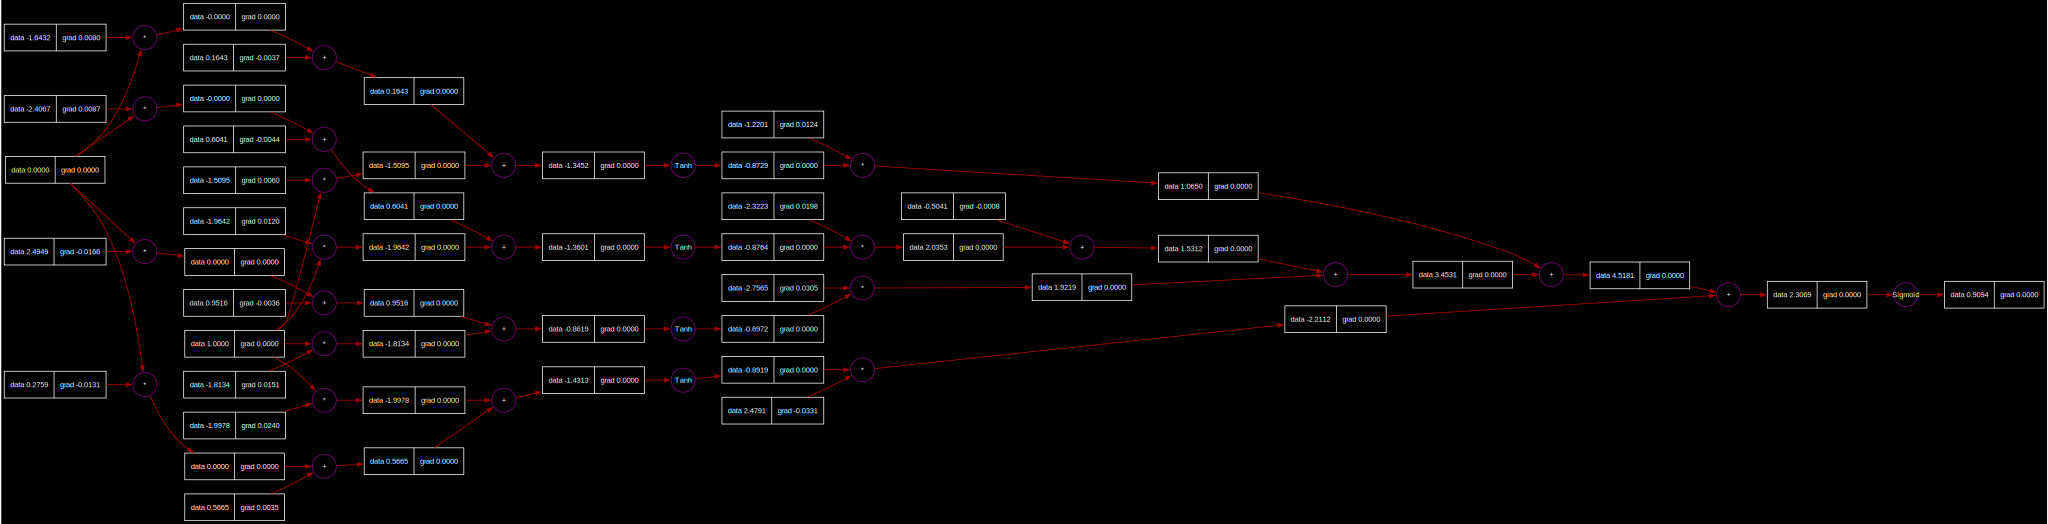

In [34]:
plot_grph(model(X[1]))